# Praticando com Dados Reais  
## Visualização de Dados na prática com dataset público de varejo (Sample Superstore)

**Objetivo do notebook**  
Aplicar boas práticas de visualização para responder perguntas reais de negócio usando um dataset público de vendas (varejo).  
Você vai praticar, de forma leve, os pontos mais relevantes da Unidade 2:

- Comparação categórica (barras, dot plot, lollipop e small multiples)  
- Séries temporais com granularidade adequada  
- Comparações no tempo (MoM, YoY e indexação)  
- Distribuição (histograma) e comparação entre grupos (boxplot)  
- Relação e correlação (scatter e heatmap)

**Dataset**  
*Sample Superstore* (dados de pedidos com data, região, categoria, vendas e lucro).  
Fonte: arquivo CSV público em repositório GitHub (acesso via `raw.githubusercontent.com`).


## 0) Preparação do ambiente

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Opcional (facilita alguns gráficos). Se preferir, pode ficar só no matplotlib.
import seaborn as sns

pd.set_option("display.max_columns", 200)
plt.rcParams["figure.dpi"] = 120


## 1) Carregar o dataset e preparar o recorte

Se o seu ambiente bloquear alguma URL, este bloco tenta um conjunto pequeno de alternativas.


In [2]:
# Dataset público (Sample Superstore) em CSV
# Fonte (raw): https://gist.githubusercontent.com/nnbphuong/38db511db14542f3ba9ef16e69d3814c/raw/3a77ff9d97c504d3ec3210b12fde7242b8c6ab63/Superstore.csv

import pandas as pd

url = "https://gist.githubusercontent.com/nnbphuong/38db511db14542f3ba9ef16e69d3814c/raw/3a77ff9d97c504d3ec3210b12fde7242b8c6ab63/Superstore.csv"
df = pd.read_csv(url)

df.head()


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


### 1.1 Padronizar colunas para o caso Superstore


In [3]:
# Validar e preparar colunas do Sample Superstore
required = {"Order Date", "Region", "Category", "Sub-Category", "Sales", "Profit"}

missing = required - set(df.columns)
if missing:
    raise ValueError(f"Dataset não possui colunas esperadas: {missing}")

df["Order Date"] = pd.to_datetime(df["Order Date"], errors="coerce")
df = df.dropna(subset=["Order Date", "Sales", "Profit", "Region", "Category", "Sub-Category"]).copy()

df.shape, df[["Order Date", "Region", "Category", "Sub-Category", "Sales", "Profit"]].head()


((9994, 21),
   Order Date Region         Category Sub-Category     Sales    Profit
 0 2017-11-08  South        Furniture    Bookcases  261.9600   41.9136
 1 2017-11-08  South        Furniture       Chairs  731.9400  219.5820
 2 2017-06-12   West  Office Supplies       Labels   14.6200    6.8714
 3 2016-10-11  South        Furniture       Tables  957.5775 -383.0310
 4 2016-10-11  South  Office Supplies      Storage   22.3680    2.5164)

## 2) Categóricos (barras, ordenação e comparação)

Pergunta real de negócio  
**Quais subcategorias mais vendem em valor de vendas?**

Vamos responder com barras ordenadas e rótulos simples.


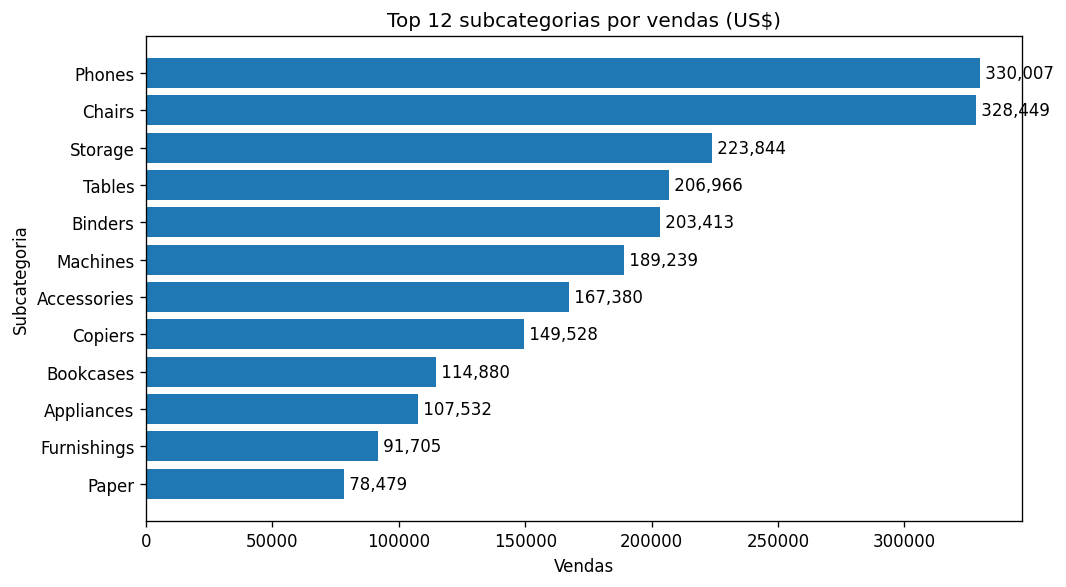

In [4]:
top = (df.groupby("Sub-Category", as_index=False)["Sales"]
         .sum()
         .sort_values("Sales", ascending=False)
         .head(12))

plot_df = top.sort_values("Sales", ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(plot_df["Sub-Category"], plot_df["Sales"])
ax.set_title("Top 12 subcategorias por vendas (US$)")
ax.set_xlabel("Vendas")
ax.set_ylabel("Subcategoria")

for i, v in enumerate(plot_df["Sales"].values):
    ax.text(v, i, f" {v:,.0f}", va="center")

plt.tight_layout()
plt.show()


## Alternativas a barras  
### Dot plot para ranking mais leve

Mesma pergunta, com menos “peso visual”.


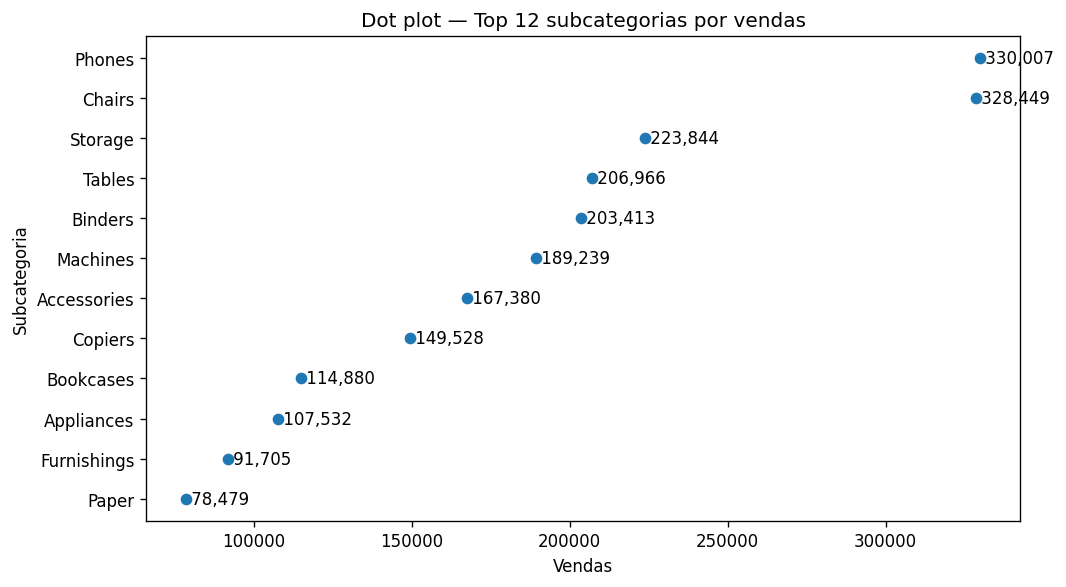

In [5]:
plot_df = top.sort_values("Sales", ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(plot_df["Sales"], plot_df["Sub-Category"])
ax.set_title("Dot plot — Top 12 subcategorias por vendas")
ax.set_xlabel("Vendas")
ax.set_ylabel("Subcategoria")

for y, x in zip(plot_df["Sub-Category"], plot_df["Sales"]):
    ax.text(x, y, f" {x:,.0f}", va="center")

plt.tight_layout()
plt.show()


### Lollipop para manter referência de base sem barras cheias

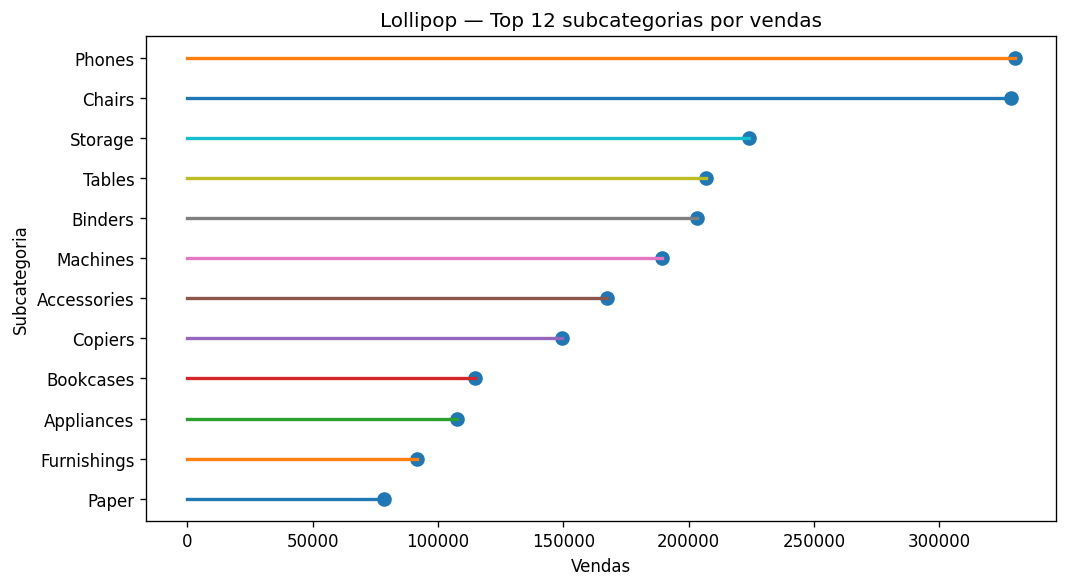

In [6]:
plot_df = top.sort_values("Sales", ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))

for y, x in zip(plot_df["Sub-Category"], plot_df["Sales"]):
    ax.plot([0, x], [y, y], linewidth=2)

ax.scatter(plot_df["Sales"], plot_df["Sub-Category"], s=60)
ax.set_title("Lollipop — Top 12 subcategorias por vendas")
ax.set_xlabel("Vendas")
ax.set_ylabel("Subcategoria")

plt.tight_layout()
plt.show()


### Small multiples para comparar subgrupos sem confusão

Pergunta  
**Como as 6 subcategorias mais vendidas se comportam por região?**


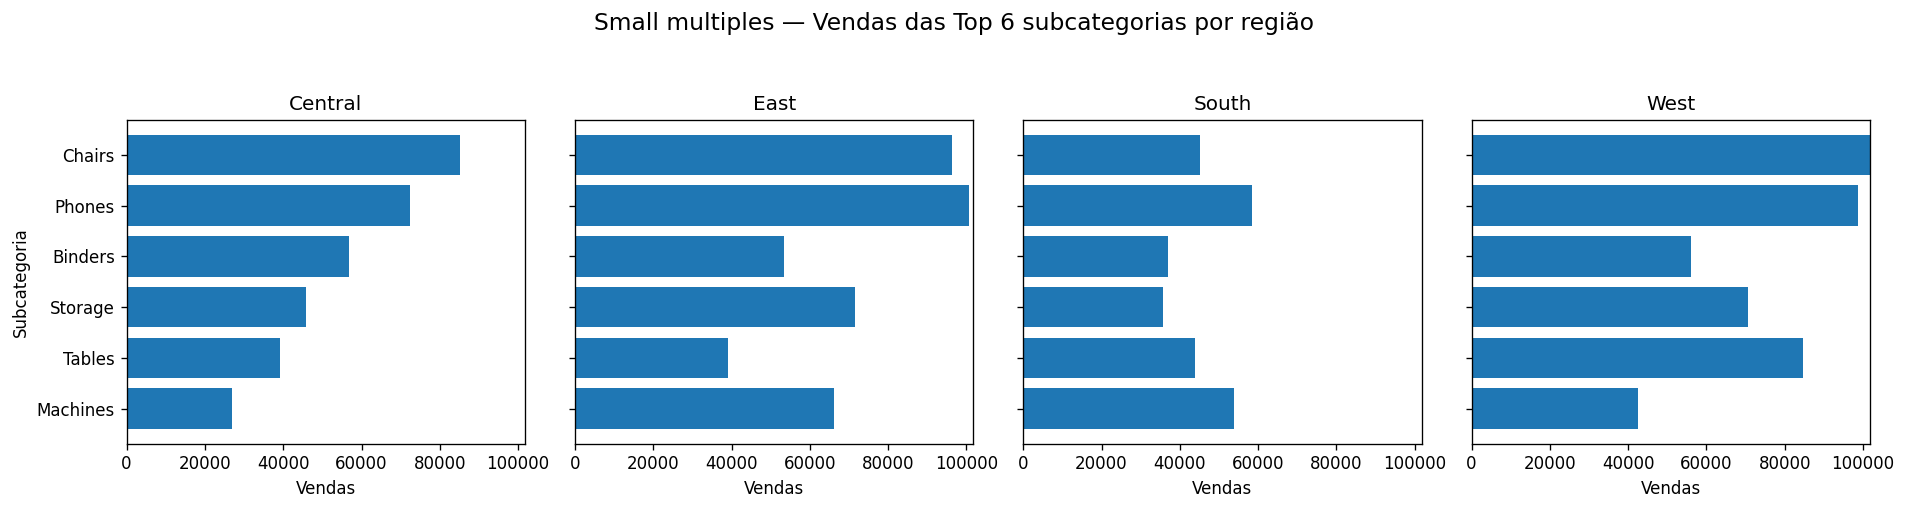

In [7]:
top6 = top.head(6)["Sub-Category"].tolist()
df6 = df[df["Sub-Category"].isin(top6)].copy()

reg = (df6.groupby(["Region", "Sub-Category"], as_index=False)["Sales"].sum())

# criar pequenos gráficos por região
regions = sorted(reg["Region"].unique())
fig, axes = plt.subplots(1, len(regions), figsize=(16, 4), sharey=True)

# FIXAR A MESMA ESCALA (X) PARA TODOS
max_global = reg["Sales"].max()

for ax, r in zip(axes, regions):
    d = reg[reg["Region"] == r].sort_values("Sales", ascending=True)
    ax.barh(d["Sub-Category"], d["Sales"])
    ax.set_title(r)
    ax.set_xlabel("Vendas")
    ax.grid(False)
    ax.invert_yaxis()

    # mesma escala em todos os gráficos
    ax.set_xlim(0, max_global)

axes[0].set_ylabel("Subcategoria")
plt.suptitle("Small multiples — Vendas das Top 6 subcategorias por região", y=1.05, fontsize=14)
plt.tight_layout()
plt.show()


## 4) Séries temporais

Pergunta  
**Como as vendas evoluem ao longo do tempo?**

Vamos trabalhar com granularidade mensal para reduzir ruído e facilitar a leitura de tendência.


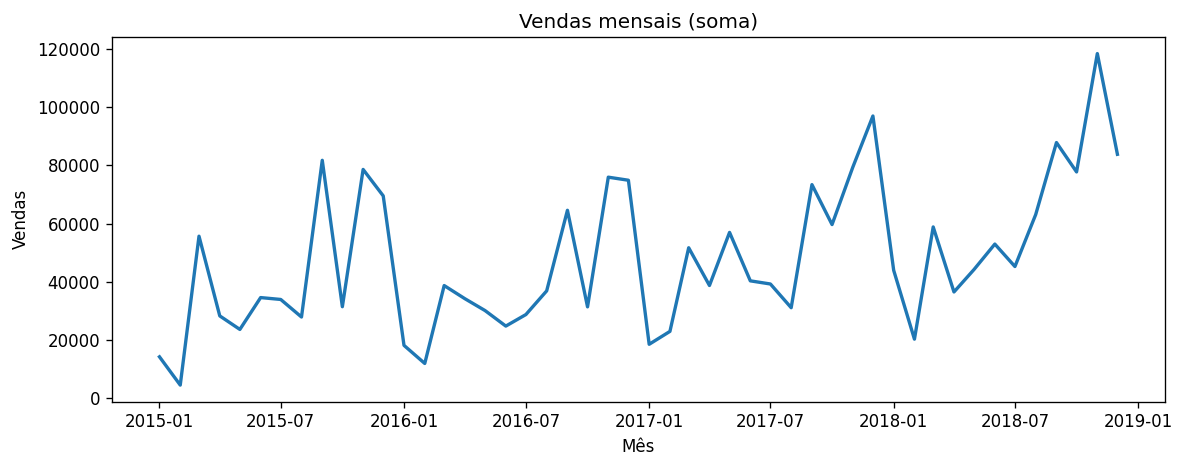

In [8]:
ts = df.set_index("Order Date").sort_index()

monthly = ts["Sales"].resample("MS").sum().to_frame("sales")

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(monthly.index, monthly["sales"], linewidth=2)
ax.set_title("Vendas mensais (soma)")
ax.set_xlabel("Mês")
ax.set_ylabel("Vendas")
plt.tight_layout()
plt.show()


## MoM, YoY e indexação

Agora vamos transformar a série mensal em comparações:

- **MoM** variação mês contra mês  
- **YoY** variação contra o mesmo mês do ano anterior


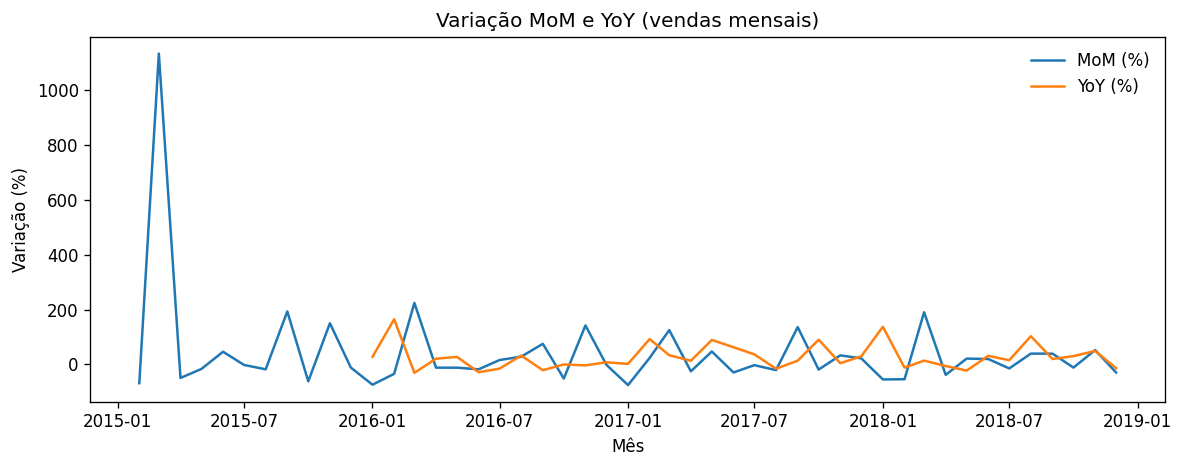

In [9]:
m = monthly.copy()

m["mom_%"] = m["sales"].pct_change() * 100
m["yoy_%"] = m["sales"].pct_change(12) * 100
m["index_100"] = (m["sales"] / m["sales"].iloc[0]) * 100

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(m.index, m["mom_%"], label="MoM (%)", linewidth=1.5)
ax.plot(m.index, m["yoy_%"], label="YoY (%)", linewidth=1.5)
ax.set_title("Variação MoM e YoY (vendas mensais)")
ax.set_xlabel("Mês")
ax.set_ylabel("Variação (%)")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


## Distribuição com histograma (bins, caudas e outliers)

Pergunta  
**Como é a distribuição do valor de venda por pedido?**

Vamos olhar `Sales` e comparar a leitura com diferentes números de bins.


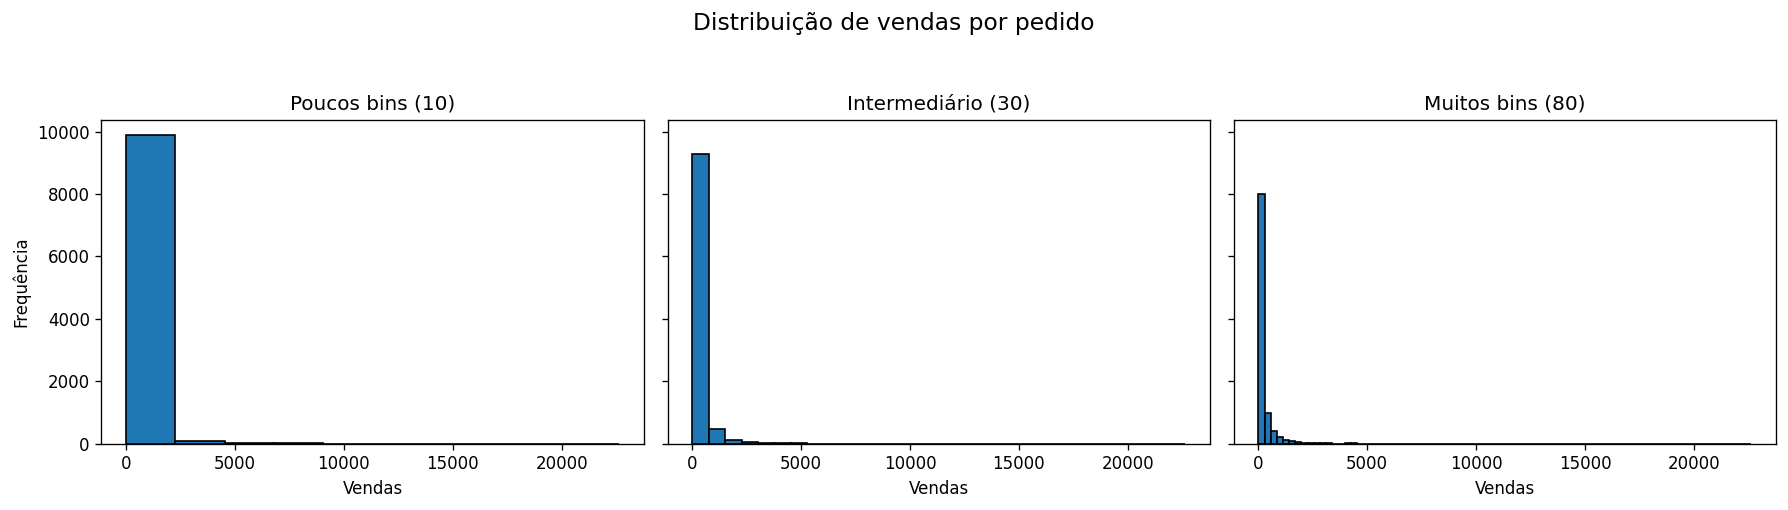

In [10]:
sales = df["Sales"].clip(lower=0)  # só para evitar eventuais valores estranhos negativos

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

axes[0].hist(sales, bins=10, edgecolor="black")
axes[0].set_title("Poucos bins (10)")
axes[0].set_xlabel("Vendas")
axes[0].set_ylabel("Frequência")

axes[1].hist(sales, bins=30, edgecolor="black")
axes[1].set_title("Intermediário (30)")
axes[1].set_xlabel("Vendas")

axes[2].hist(sales, bins=80, edgecolor="black")
axes[2].set_title("Muitos bins (80)")
axes[2].set_xlabel("Vendas")

plt.suptitle("Distribuição de vendas por pedido", y=1.05, fontsize=14)
plt.tight_layout()
plt.show()


## Boxplot para comparar distribuições entre grupos

Pergunta  
**O ticket (Sales) varia muito entre regiões?**


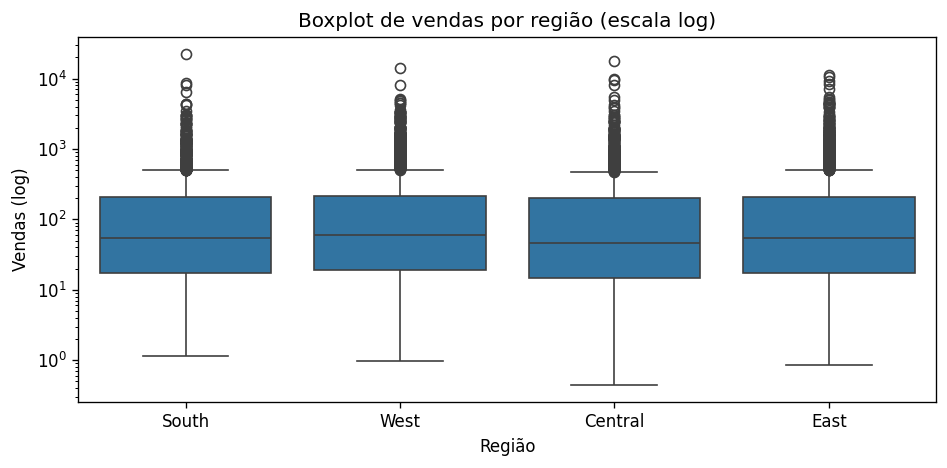

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x="Region", y="Sales")
plt.yscale("log")

plt.title("Boxplot de vendas por região (escala log)")
plt.xlabel("Região")
plt.ylabel("Vendas (log)")
plt.tight_layout()
plt.show()


## 8) Relação e correlação

Pergunta  
**Vendas mais altas tendem a gerar mais lucro?**

Vamos:
- usar scatter para ver relação e outliers  
- usar heatmap para ver correlação entre variáveis numéricas


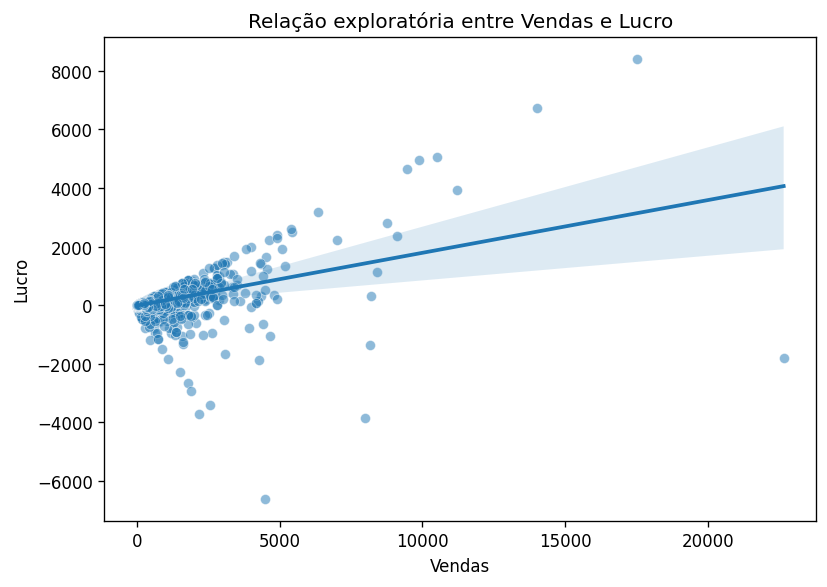

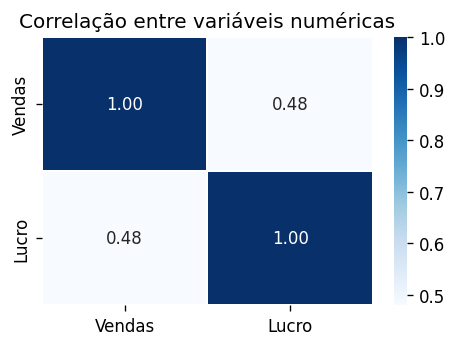

In [12]:
# Scatter Sales vs Profit
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x="Sales", y="Profit", alpha=0.5)
sns.regplot(data=df, x="Sales", y="Profit", scatter=False)
plt.title("Relação exploratória entre Vendas e Lucro")
plt.xlabel("Vendas")
plt.ylabel("Lucro")
plt.tight_layout()
plt.show()

# Heatmap com correlação (variáveis numéricas)
num = df[["Sales", "Profit"]].copy()
num=num.rename(columns=({"Sales":"Vendas", "Profit":"Lucro"}))
corr = num.corr()

plt.figure(figsize=(4, 3))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="Blues", linewidths=1)
plt.title("Correlação entre variáveis numéricas")
plt.tight_layout()
plt.show()


## Encerramento

Você acabou de construir um mini relatório exploratório com um dataset real de varejo:

- ranking de subcategorias com leitura rápida  
- comparações por região sem confusão  
- série temporal com granularidade adequada  
- comparações MoM e YoY  
- distribuição e variabilidade por grupo  
- relações entre variáveis e correlação